# Choose seed points, assign demand, run GA and plot networks

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from typing import List

## Seed points

Start with a rectangle shape for a city (we'll switch to a real city and street network later), then create a grid of seed points over that shape.

In [2]:
import shapely
from shapely import Polygon, LineString, LinearRing, Point

In [3]:
coords = [(0., 0.), (0., 100.), (100., 100.), (100., 0.)]

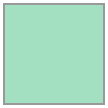

In [4]:
city = Polygon(coords)
city

### Hexagons

The code in this section is inspired by ideas and code from Red Blob Games:
- https://www.redblobgames.com/grids/hexagons/
- https://www.redblobgames.com/grids/hexagons/implementation.html
- https://www.redblobgames.com/grids/parts/

![Hex Sizes](../../red-blob-games/hex_size.png "Hex Sizes")

![Hex Angles](../../red-blob-games/hex_angles.png "Hex Angles")

![Cube Coords](../../red-blob-games/cube_coords.png "Cube Coords")

![Axial Coords](../../red-blob-games/axial_coords.png "Axial Coords")

In [133]:
def hex_corner(centre: shapely.Point, size: float, i: int, pointy: bool) -> shapely.Point:
    """Produces the ith corner of a regular hexagon as a Shapely point.
    
    Args:
        centre: The centre of the hexagon.
        size: The distance from the hexagon's centre to one of its corners.
        i: Which corner (out of 6).
        pointy: Whether the hexagon should be pointy-top or flat-top.
    
    Returns:
        A shapely.Point representing the ith corner of a hexagon.
    """
    if pointy:
        angle_deg = 60 * (i+1) - 30
    else:
        angle_deg = 60 * i
    angle_rad = np.pi / 180 * angle_deg
    print(f"Point {i}: {angle_deg} degrees")
    return Point(centre.x + size * np.cos(angle_rad),
                 centre.y + size * np.sin(angle_rad))

def hex_corner_flat(centre: shapely.Point, size: float, i: int) -> shapely.Point:
    """Produces the ith corner of a flat-top regular hexagon as a Shapely point.
    
    Args:
        centre: The centre of the hexagon.
        size: The distance from the hexagon's centre to one of its corners.
        i: Which corner (out of 6).
    
    Returns:
        A shapely.Point representing the ith corner of a hexagon.
    """
    hex_corner(centre, size, i, False)

def hex_corner_pointy(centre: shapely.Point, size: float, i: int) -> shapely.Point:
    """Produces the ith corner of a pointy-top regular hexagon as a Shapely point.
    
    Args:
        centre: The centre of the hexagon.
        size: The distance from the hexagon's centre to one of its corners.
        i: Which corner (out of 6).
    
    Returns:
        A shapely.Point.
    """
    hex_corner(centre, size, i, True)

In [134]:
def get_hex_vertices(centre: shapely.Point, size: float, pointy: bool) -> List[shapely.Point]:
    """Returns a list of hexagon corners as Shapely points.
    
    Args:
        centre: The centre of the hexagon.
        size: The distance from the hexagon's centre to one of its corners.
        pointy: Whether the hexagon should be pointy-top or flat-top.
    
    Returns:
        A list of Shapely points.
    """
    coords = []
    for i in range(0,6):
        coords.append(hex_corner(centre, size, i, pointy))
    return coords

In [137]:
# TODO: degrees are increasing counterclockwise,
#    I would rather have them increase clockwise

def create_hexagon(centre: shapely.Point, size: float, pointy: bool, polygon: bool) -> shapely.Polygon:
    """Creates a regular hexagon as a Shapely polygon or curve.
    
    Args:
        centre: The centre of the hexagon.
        size: The distance from the hexagon's centre to one of its corners.
        pointy: Whether the hexagon should be pointy-top or flat-top.
        as_polygon: Whether the hexagon should be a Shapely Polygon or LinearRing.
    
    Returns:
        A regular hexagon.
    """
    coords = get_hex_vertices(centre, size, pointy)
    if polygon:
        return Polygon(coords)
    else:
        return LinearRing(coords)

Point 0: 30 degrees
Point 1: 90 degrees
Point 2: 150 degrees
Point 3: 210 degrees
Point 4: 270 degrees
Point 5: 330 degrees


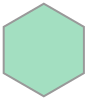

In [138]:
centre_ex = Point(50., 50.)
size_ex = 5

my_hex_poly = create_hexagon(centre_ex, size_ex, True, True)
my_hex_poly

Point 0: 0 degrees
Point 1: 60 degrees
Point 2: 120 degrees
Point 3: 180 degrees
Point 4: 240 degrees
Point 5: 300 degrees


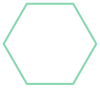

In [139]:
my_hex_line = create_hexagon(centre_ex, size_ex, False, False)
my_hex_line

In [140]:
len(my_hex_line.coords)

7

In [141]:
# Next step... create grid of hexagon vertices over the 'city' shape
# See https://www.redblobgames.com/grids/hexagons/ and https://www.redblobgames.com/grids/hexagons/implementation.html


In a rectangle from (0,0) to (X, Y):

while x<X and y<Y

For pointy
Set height = 2 * size
Set width = sqrt(3) * size

Y-AXIS:

1st col (x=0), and every odd col:
1. Set 1st vertex at y=0.25\*height
2. Set 2nd vertex at y=0.75\*height (increase by 0.5\*height)
3. Set 3rd vertex at y=1.75\height (increase by 1\*height)
So: Start at y=0.25\*height; when i is even, set vertex at y = y + 0.5\*height; when i is odd, set vertex at y = y + 1\*height

2nd col (x=0.5\*width), and every even col:
1. Set 1st vertex at y=0*height
2. Set 2nd vertex at y=1\*height (increase by 1\*height)
3. Set 3rd vertex at y=1.5\height (increase by 0.5\*height)
So: Start at y=0\*height; when i is even, set vertex at y = y + 1\*height; when i is odd, set vertex at y = y + 0.5\*height

X-AXIS:

1st row (y=0):
1. Set 1st vertex at x=0.5\*width
2. Set 2nd vertex at x=1.5\*width (increase by 1\*width)
3. Set 3rd vertex at x=2.5\width (increase by 1\*width)
So: Start at x=0.5\*width; set succeeding vertices at x = x + 1\*width (increase x by 1\*width every time)

2nd row (y=0.25\*height):
1. Set 1st vertex at x=0\*width
2. Set 2nd vertex at x=1\*width (increase by 1\*width)
3. Set 3rd vertex at x=2\width (increase by 1\*width)
So: Start at x=0\*width; set succeeding vertices at x = x + 1\*width (increase x by 1\*width every time)

3rd row: same as 2nd row
4th row: same as 1st row
5th row: same as 1st row
6th row: same as 2nd+3rd row
7th row: same as 2nd+3rd row


In [ ]:
# Try to make just one column first

def create_hex_grid(hex_size: int, X, Y):
    seed_points = []
    hex_height = 2 * hex_size
    hex_width = math.sqrt(3) * hex_size
    row = 0
    x = 0
    
    while x < X:
        col = 0
        y = 0
        while y < Y:
            if col % 2 == 0:
                y = 0.25 * hex_height
            
            col = col + 1

    # even cols:
    
        
    